# model traning

In [120]:
import os

print(os.getcwd())

d:\Customer A & R\notebooks


In [121]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

# loading dataset

In [122]:
data = pd.read_csv(r"D:\Customer A & R\data\processed\cleaned.csv")

In [123]:
data.head()

,Customer_ID,Subscription_Length,Customer_Satisfaction,Daily_Watch_Time,Engagement_Rate,Device,Genre,Region,Payment_History,Subscription_Plan,Churn,Support_Queries,Age,Monthly_Income,Promotional_Offers,Profiles_Created,Days_Since_Last_Activity
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2,4
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5,71
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5,50
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4,10
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5,59


In [124]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1000 non-null   str    
 1   Subscription_Length       1000 non-null   int64  
 2   Customer_Satisfaction     1000 non-null   int64  
 3   Daily_Watch_Time          1000 non-null   float64
 4   Engagement_Rate           1000 non-null   int64  
 5   Device                    1000 non-null   str    
 6   Genre                     1000 non-null   str    
 7   Region                    1000 non-null   str    
 8   Payment_History           1000 non-null   str    
 9   Subscription_Plan         1000 non-null   str    
 10  Churn                     1000 non-null   str    
 11  Support_Queries           1000 non-null   int64  
 12  Age                       1000 non-null   int64  
 13  Monthly_Income            1000 non-null   int64  
 14  Promotional_Offers  

In [125]:
data.shape

(1000, 17)

In [126]:
data.isnull().sum()

Customer_ID                 0
Subscription_Length         0
Customer_Satisfaction       0
Daily_Watch_Time            0
Engagement_Rate             0
Device                      0
Genre                       0
Region                      0
Payment_History             0
Subscription_Plan           0
Churn                       0
Support_Queries             0
Age                         0
Monthly_Income              0
Promotional_Offers          0
Profiles_Created            0
Days_Since_Last_Activity    0
dtype: int64

In [127]:
data.dtypes

Customer_ID                     str
Subscription_Length           int64
Customer_Satisfaction         int64
Daily_Watch_Time            float64
Engagement_Rate               int64
Device                          str
Genre                           str
Region                          str
Payment_History                 str
Subscription_Plan               str
Churn                           str
Support_Queries               int64
Age                           int64
Monthly_Income                int64
Promotional_Offers            int64
Profiles_Created              int64
Days_Since_Last_Activity      int64
dtype: object

In [128]:
categorical_columns = data.select_dtypes(include="object").columns

categorical_columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_6884\3251772235.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include="object").columns


Index(['Customer_ID', 'Device', 'Genre', 'Region', 'Payment_History',
       'Subscription_Plan', 'Churn'],
      dtype='str')

In [129]:
data.drop("Customer_ID", axis=1, inplace=True)

In [130]:
data.columns

Index(['Subscription_Length', 'Customer_Satisfaction', 'Daily_Watch_Time',
       'Engagement_Rate', 'Device', 'Genre', 'Region', 'Payment_History',
       'Subscription_Plan', 'Churn', 'Support_Queries', 'Age',
       'Monthly_Income', 'Promotional_Offers', 'Profiles_Created',
       'Days_Since_Last_Activity'],
      dtype='str')

# label encoding

In [131]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Device",
    "Genre",
    "Region",
    "Payment_History",
    "Subscription_Plan",
    "Churn"
]

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [132]:
data.head()

,Subscription_Length,Customer_Satisfaction,Daily_Watch_Time,Engagement_Rate,Device,Genre,Region,Payment_History,Subscription_Plan,Churn,Support_Queries,Age,Monthly_Income,Promotional_Offers,Profiles_Created,Days_Since_Last_Activity
0,12,10,4.85,4,4,0,2,1,0,0,10,33,6250,5,2,4
1,12,8,1.75,9,1,6,2,1,0,1,9,28,7018,1,5,71
2,3,4,2.75,9,3,1,1,1,1,1,3,18,1055,1,5,50
3,3,7,3.00,9,3,3,2,0,1,0,5,32,6707,5,4,10
4,24,2,1.37,5,2,3,3,1,2,1,2,59,1506,3,5,59


In [133]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Subscription_Length       1000 non-null   int64  
 1   Customer_Satisfaction     1000 non-null   int64  
 2   Daily_Watch_Time          1000 non-null   float64
 3   Engagement_Rate           1000 non-null   int64  
 4   Device                    1000 non-null   int64  
 5   Genre                     1000 non-null   int64  
 6   Region                    1000 non-null   int64  
 7   Payment_History           1000 non-null   int64  
 8   Subscription_Plan         1000 non-null   int64  
 9   Churn                     1000 non-null   int64  
 10  Support_Queries           1000 non-null   int64  
 11  Age                       1000 non-null   int64  
 12  Monthly_Income            1000 non-null   int64  
 13  Promotional_Offers        1000 non-null   int64  
 14  Profiles_Created    

In [134]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [135]:
print(X.shape)
print(y.shape)

(1000, 15)
(1000,)


# trai test split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 15)
X_test : (200, 15)
y_train: (800,)
y_test : (200,)


# create random forest model

In [138]:
# Create Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [139]:
# Train Random Forest Model

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [140]:
# Make Predictions
rf_predictions = rf_model.predict(X_test)

In [141]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

In [142]:
# Predict using Random Forest

rf_predictions = rf_model.predict(X_test)# Evaluate Random Forest Model

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.995

Confusion Matrix
[[ 89   0]
 [  1 110]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        89
           1       1.00      0.99      1.00       111

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [143]:
# Save Random Forest Model

joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [144]:
# create decision tree model

In [145]:
# Create Decision Tree Model

dt_model = DecisionTreeClassifier(
    random_state=42
)

In [146]:
# Train Decision Tree Model

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [147]:
# Predict using Decision Tree

dt_predictions = dt_model.predict(X_test)

In [148]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

In [149]:
# Evaluate Decision Tree Model

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_predictions))

print("\nClassification Report")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.995

Confusion Matrix
[[ 89   0]
 [  1 110]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        89
           1       1.00      0.99      1.00       111

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [150]:
# Save Decision Tree Model

joblib.dump(dt_model, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

In [151]:
# Create XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

In [152]:
# Train XGBoost Model

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [153]:
# Predict using XGBoost

xgb_predictions = xgb_model.predict(X_test)

In [154]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

In [155]:
# Evaluate XGBoost Model

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_predictions))

print("\nClassification Report")
print(classification_report(y_test, xgb_predictions))

XGBoost Accuracy: 1.0

Confusion Matrix
[[ 89   0]
 [  0 111]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00       111

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [156]:
# Save XGBoost Model

joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']

# Model Comparison

In [157]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "XGBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        dt_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.995
1,Decision Tree,0.995
2,XGBoost,1.000


In [158]:
print(repr(rf_accuracy))
print(repr(dt_accuracy))
print(repr(xgb_accuracy))

0.995
0.995
1.0


In [159]:
best_accuracy = comparison["Accuracy"].max()

best_models = comparison[
    comparison["Accuracy"] == best_accuracy
]

print("Best Model(s):")
print(best_models)

Best Model(s):
     Model  Accuracy
2  XGBoost       1.0


In [160]:
comparison.to_csv("../reports/model_comparison.csv", index=False)

In [161]:
comparison.to_csv("../reports/model_comparison.csv", index=False)

In [162]:
loaded_model = joblib.load("../models/xgboost.pkl")

In [163]:
sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print(sample_prediction)

[1]


In [164]:
import joblib

model_scores = {
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "XGBoost": xgb_accuracy
}

joblib.dump(model_scores, "../models/model_scores.pkl")

print("Model scores saved successfully!")

Model scores saved successfully!


In [165]:
joblib.dump(list(X.columns), "../models/features.pkl")

print("Features saved successfully!")

Features saved successfully!


In [166]:
joblib.dump(label_encoders, "../models/label_encoders.pkl")

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [167]:
print(model_scores)

{'Decision Tree': 0.995, 'Random Forest': 0.995, 'XGBoost': 1.0}


In [168]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [dt_accuracy, rf_accuracy, xgb_accuracy]
})

print(comparison)

best_accuracy = comparison["Accuracy"].max()
best_models = comparison[comparison["Accuracy"] == best_accuracy]

print("\nBest Model(s):")
print(best_models)

           Model  Accuracy
0  Decision Tree     0.995
1  Random Forest     0.995
2        XGBoost     1.000

Best Model(s):
     Model  Accuracy
2  XGBoost       1.0


In [169]:
print(xgb_model.classes_)

[0 1]


In [170]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [171]:
print(data["Churn"].value_counts())

print("\nPercentage")

print(data["Churn"].value_counts(normalize=True) * 100)

Churn
1    539
0    461
Name: count, dtype: int64

Percentage
Churn
1    53.9
0    46.1
Name: proportion, dtype: float64


In [172]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.99 0.98 1.   1.   1.  ]
Average Accuracy: 0.994


In [173]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
14  Days_Since_Last_Activity    0.898713
2           Daily_Watch_Time    0.027688
5                      Genre    0.019968
10                       Age    0.009402
11            Monthly_Income    0.009324
6                     Region    0.008895
3            Engagement_Rate    0.007455
1      Customer_Satisfaction    0.005002
9            Support_Queries    0.004697
4                     Device    0.003139
7            Payment_History    0.002704
13          Profiles_Created    0.001751
12        Promotional_Offers    0.001262
0        Subscription_Length    0.000000
8          Subscription_Plan    0.000000


In [174]:
joblib.dump(
    xgb_model.feature_importances_,
    "../models/feature_importance.pkl"
)

['../models/feature_importance.pkl']

In [175]:
import joblib

fi = joblib.load("../models/feature_importance.pkl")

print(type(fi))

print(fi)

<class 'numpy.ndarray'>
[0.         0.00500203 0.02768815 0.00745461 0.00313918 0.01996831
 0.00889536 0.00270406 0.         0.00469669 0.00940151 0.00932438
 0.00126179 0.00175083 0.8987131 ]


In [176]:
print(X_train.index.intersection(X_test.index))

Index([], dtype='int64')


In [177]:
print(data.groupby("Churn")["Days_Since_Last_Activity"].describe())

       count       mean        std   min   25%   50%   75%   max
Churn                                                           
0      461.0  16.542299   8.548128   0.0  10.0  17.0  24.0  30.0
1      539.0  51.163265  15.112443  30.0  39.0  49.0  59.0  90.0


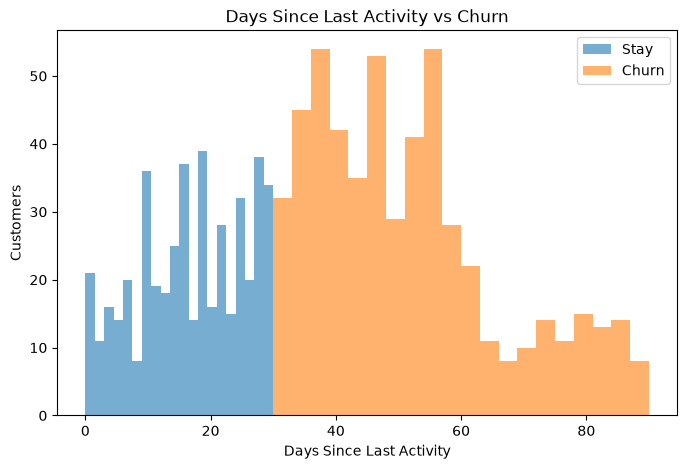

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    data[data["Churn"]==0]["Days_Since_Last_Activity"],
    bins=20,
    alpha=0.6,
    label="Stay"
)

plt.hist(
    data[data["Churn"]==1]["Days_Since_Last_Activity"],
    bins=20,
    alpha=0.6,
    label="Churn"
)

plt.xlabel("Days Since Last Activity")
plt.ylabel("Customers")
plt.title("Days Since Last Activity vs Churn")
plt.legend()

plt.show()

In [179]:
import joblib

print("Scores:")
print(joblib.load("../models/model_scores.pkl"))

print("\nFeature Importance:")
print(joblib.load("../models/feature_importance.pkl"))

Scores:
{'Decision Tree': 0.995, 'Random Forest': 0.995, 'XGBoost': 1.0}

Feature Importance:
[0.         0.00500203 0.02768815 0.00745461 0.00313918 0.01996831
 0.00889536 0.00270406 0.         0.00469669 0.00940151 0.00932438
 0.00126179 0.00175083 0.8987131 ]
